### Imports and Configurations

In [18]:
%load_ext autoreload
%autoreload 2
%matplotlib inline

from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import pearsonr, spearmanr

# --- Import from your new libraries ---
from src.data_loader import *
from src.ism_utils import *

# --- Config ---
CHROM_ID = "dChr"
FA_PATH = Path("Data/genome/dChr.fa")

# Genomic ISM maps paths
ISM_GENOMIC_FWD = "ISM/Maps/dChr/genomic_model_chr_dChr_fwd.dat"
ISM_GENOMIC_REV = "ISM/Maps/dChr/genomic_model_chr_dChr_rev.dat"

# Random ISM maps paths
ISM_RANDOM_FWD  = "ISM/Maps/dChr/dChr_model_chr_dChr_fwd.dat"
ISM_RANDOM_REV  = "ISM/Maps/dChr/dChr_model_chr_dChr_rev.dat"

# Model paths
GENOMIC_MODEL = "Distillation/genomic/student_genomic_distilled.h5"
RANDOM_MODEL = "Distillation/dChr/student_dChr_distilled.h5"
PARAMS_JSON = "Models/shorkie/params.json"

# Normalized coverage data paths
NPZ_COV_FWD = "Data/normalized_expression/dChr_fwd_norm.npz"
NPZ_COV_REV = "Data/normalized_expression/dChr_rev_norm.npz"

# Motif database path
MEME_DB_PATH     =  "Data/motifs/SwissRegulon.meme"       #"Data/motifs/YeTFaSCo.meme"

# Analysis Parameters
WINDOW_SIZE = 150

# P-val threshold for motif scanning
threshold = 0.001

# Normalization mean and std for inverse-transform of predictions
mu_r, sigma_r = 4.1016,1.9481
mu_g, sigma_g = 1.7390, 1.8168

# Output directory for saved figures
OUT_DIR = Path("ISM/Notebook_output/dChr/disagreement_windows_with_profiles")
OUT_DIR.mkdir(parents=True, exist_ok=True)



The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


### Load data

In [2]:
# 1. Load Sequence
full_seq = fetch_chr_seq(FA_PATH, CHROM_ID)
L = len(full_seq)
fwd_seq = full_seq
rev_seq = str(Seq(fwd_seq).reverse_complement())

print(f"Loaded sequence length: {L}")

# 2. Load ISM Scores (Memmap)
# FWD ISM scores
ism_gen_fwd = np.array(np.memmap(ISM_GENOMIC_FWD, dtype="float32", mode="r", shape=(len(full_seq), 4)))
ism_rand_fwd = np.array(np.memmap(ISM_RANDOM_FWD, dtype="float32", mode="r", shape=(len(full_seq), 4)))

# REV ISM scores
ism_gen_rev = np.array(np.memmap(ISM_GENOMIC_REV, dtype="float32", mode="r", shape=(len(full_seq), 4)))
ism_rand_rev = np.array(np.memmap(ISM_RANDOM_REV, dtype="float32", mode="r", shape=(len(full_seq), 4)))

# 3. Compute nucleotide level contributions from ISM matrices
_, attr_gen_fwd = compute_attr_from_ism(ism_gen_fwd, fwd_seq)
_, attr_gen_rev = compute_attr_from_ism(ism_gen_rev, rev_seq)

_, attr_rand_fwd = compute_attr_from_ism(ism_rand_fwd, fwd_seq)
_, attr_rand_rev = compute_attr_from_ism(ism_rand_rev, rev_seq)

# One-hot encode fwd & rev sequence
onehot_fwd = one_hot(fwd_seq).astype(np.float32)
onehot_rev = one_hot(rev_seq).astype(np.float32)


Loaded sequence length: 254886


### Compute correlations

Compute window correlations

In [3]:

def windowed_corr(x, y, win=400, stride=200, method="pearson", min_valid=10):
    """
    Sliding-window correlation between x and y.
    method: "pearson" or "spearman"
    min_valid: minimum number of finite paired points required in a window
    Returns:
        starts : (n_windows,) window start indices
        corrs  : (n_windows,) correlation per window (NaN if not computable)
    """
    x = np.asarray(x)
    y = np.asarray(y)
    assert x.shape == y.shape

    L = len(x)
    starts = np.arange(0, L - win + 1, stride, dtype=int)
    corrs = np.full(len(starts), np.nan, dtype=float)

    for i, s in enumerate(starts):
        a = x[s:s+win]
        b = y[s:s+win]

        # keep only finite pairs
        m = np.isfinite(a) & np.isfinite(b)
        if m.sum() < min_valid:
            continue

        a = a[m]
        b = b[m]

        # constant windows (after filtering)
        if np.all(a == a[0]) or np.all(b == b[0]):
            continue

        if method == "pearson":
            corrs[i] = pearsonr(a, b)[0]
        elif method == "spearman":
            corrs[i] = spearmanr(a, b)[0]
        else:
            raise ValueError("method must be 'pearson' or 'spearman'")

    return starts, corrs

### Generate correlation statistics

In [4]:
## generate correlations for both fwd and rev strands
_ , corrs_fwd = windowed_corr(attr_gen_fwd, attr_rand_fwd, win=150, stride=75, method="pearson")
_ , corrs_rev = windowed_corr(attr_gen_rev, attr_rand_rev, win=150, stride=75, method="pearson")

corrs = np.concatenate([corrs_fwd, corrs_rev])

valid = corrs[np.isfinite(corrs)]
print("Number of windows:", len(corrs))
print("Valid correlations:", len(valid))
print("Median Pearson r:", np.median(valid))
print("Mean Pearson r:", np.mean(valid))

Number of windows: 6794
Valid correlations: 6504
Median Pearson r: 0.08785894379266883
Mean Pearson r: 0.06671816811422938


### Plot correlations histogrm

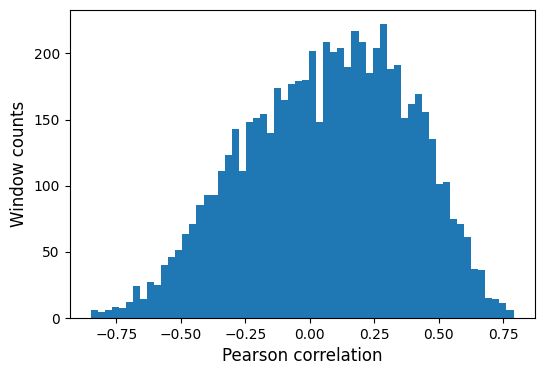

In [5]:
plt.figure(figsize=(6,4))
plt.hist(valid, bins=60)
plt.xlabel("Pearson correlation",size=12)
plt.ylabel("Window counts",size=12)
# plt.title("Windowed Spearman correlations")
# plt.axvline(np.median(valid), linestyle="--")
# plt.savefig("ISM/correlations_histogram", dpi=300)
plt.show()

### Handle Nan values

In [6]:
# Examine Nans in attribution maps
print("NaNs genomic fwd:", np.sum(np.isnan(attr_gen_fwd)))
print("NaNs genomic rev:", np.sum(np.isnan(attr_gen_rev)))
print("NaNs random fwd:", np.sum(np.isnan(attr_rand_fwd)))
print("NaNs random rev:", np.sum(np.isnan(attr_rand_rev)))

# Turn Nans to zeros
attr_gen_fwd = np.nan_to_num(attr_gen_fwd, nan=0.0, posinf=0.0, neginf=0.0)
attr_gen_rev = np.nan_to_num(attr_gen_rev, nan=0.0, posinf=0.0, neginf=0.0)

attr_rand_fwd = np.nan_to_num(attr_rand_fwd, nan=0.0, posinf=0.0, neginf=0.0)
attr_rand_rev = np.nan_to_num(attr_rand_rev, nan=0.0, posinf=0.0, neginf=0.0)

NaNs genomic fwd: 0
NaNs genomic rev: 0
NaNs random fwd: 0
NaNs random rev: 0


### Find & Annotate Seqlets

In [15]:
# attr_gen_fwd, attr_gen_rev are shape (L,)
attr_gen= np.stack([attr_gen_fwd, attr_gen_rev], axis=0)

# same for random
attr_rand = np.stack([attr_rand_fwd, attr_rand_rev], axis=0)

print("Shape of concatenated attributions: ", attr_gen.shape)

onehot = np.stack([onehot_fwd, onehot_rev], axis=0)

# 1. Find Seqlets (Regions of high importance)

s_gen = find_seqlets(attr_gen, threshold=threshold)
s_rand = find_seqlets(attr_rand, threshold=threshold)

print(f"Found {len(s_gen)} genomic seqlets and {len(s_rand)} random/Mpneumo seqlets.")

# 2. Annotate with Motifs
print(f"Annotating with {MEME_DB_PATH}...")
s_gen = annotate_seqlets_with_motifs(s_gen, onehot, MEME_DB_PATH)
s_rand = annotate_seqlets_with_motifs(s_rand, onehot, MEME_DB_PATH)

# Optional: Peek at the top motifs found
print("\nTop Motifs found in Random Model:")
print(s_rand[s_rand.motif_name != "NA"].motif_name.value_counts())

Shape of concatenated attributions:  (2, 254886)
Found 425 genomic seqlets and 1794 random/Mpneumo seqlets.
Annotating with Data/motifs/SwissRegulon.meme...
X_seq shape:  torch.Size([2, 4, 254886])
Significant motif hits kept: 91
Unique seqlets annotated: NA
X_seq shape:  torch.Size([2, 4, 254886])
Significant motif hits kept: 491
Unique seqlets annotated: NA

Top Motifs found in Random Model:
SIG1     69
RGM1     54
CBF1     23
REB1     20
STB3     17
         ..
RSC3      1
GSM1      1
PDR1      1
STB1      1
TOS8      1
Name: motif_name, Length: 81, dtype: int64


In [8]:
print(s_rand[s_rand.motif_name != "NA"].motif_name.unique().tolist())

['RGM1 ', 'SIG1 ', 'RIM101 ', 'STB3 ', 'REB1 ', 'HAC1 ', 'SWI5 ', 'AZF1 ', 'RPN4 ', 'UME6 ', 'YPR022C ', 'SFP1 ', 'YER130C ', 'GIS1 ', 'HAP4 ', 'HAP3 ', 'HAP5 ', 'REI1 ', 'USV1 ', 'PBF1 ', 'PBF2 ', 'SKO1 ', 'YAP3 ', 'RPH1 ', 'MATALPHA2 ', 'ABF2 ', 'NDT80 ', 'CST6 ', 'FZF1 ', 'PDR3 ', 'MSN4 ', 'MSN2 ', 'TBF1 ', 'HMRA2 ', 'BAS1 ', 'CBF1 ', 'RTG3 ', 'TYE7 ', 'STP3 ', 'SPT15 ', 'NHP6A ', 'YOX1 ', 'AFT2 ', 'RSC3 ', 'INO4 ', 'INO2 ', 'YML081W ', 'DAL80 ', 'GAT1 ', 'SIP4 ', 'SNT2 ', 'SUT2 ', 'NHP10 ', 'ORC1 ', 'STE12 ', 'SWI4 ', 'SWI6 ', 'STB1 ', 'PDR1 ', 'GSM1 ', 'CAT8 ', 'YLR278C ', 'CAD1 ', 'TEC1 ', 'YPR015C ', 'FKH2 ', 'FKH1 ', 'HCM1 ', 'TBS1 ', 'CUP9 ', 'ROX1 ', 'GZF3 ', 'STB4 ', 'ACE2 ', 'ZMS1 ', 'EDS1 ', 'GCN4 ', 'CHA4 ', 'UGA3 ', 'CIN5 ', 'TOS8 ']


### Load models for prediction

In [9]:

from baskerville.seqnn import SeqNN
import json

def load_model(model_path):

    with open(PARAMS_JSON) as f:
        params = json.load(f)

    params["model"]["num_features"] = 170
    m = SeqNN(params["model"])
    trunk_out = m.model_trunk.output
    
    # Distillation Head
    y = tf.keras.layers.Dense(1, name="distill_head")(trunk_out)
    y = tf.keras.layers.Lambda(lambda t: tf.squeeze(t, -1))(y)
    student = tf.keras.Model(inputs=m.model.input, outputs=y)

    # --- Weight Check ---
    head_layer = student.get_layer("distill_head")
    head_before = [w.numpy() for w in head_layer.weights]
    trunk_before = [w.numpy().copy() for w in m.model_trunk.weights]

    # load weights
    student.load_weights(model_path)

    # ensure weights changed
    head_after = [w.numpy() for w in head_layer.weights]
    trunk_after = [w.numpy() for w in m.model_trunk.weights]

    trunk_changed = any(np.any(b != a) for b, a in zip(trunk_before, trunk_after))
    head_changed  = any(np.any(b != a) for b, a in zip(head_before, head_after))

    print(f"    Trunk weights changed? {trunk_changed}")
    print(f"    Head weights changed?  {head_changed}")

    return student

genomic_model = load_model(GENOMIC_MODEL)
random_model  = load_model(RANDOM_MODEL)


2026-01-17 11:14:57.615728: I tensorflow/core/common_runtime/gpu/gpu_device.cc:1929] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 78238 MB memory:  -> device: 0, name: NVIDIA A100 80GB PCIe, pci bus id: 0000:65:00.0, compute capability: 8.0
2026-01-17 11:14:57.617073: I tensorflow/core/common_runtime/gpu/gpu_device.cc:1929] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 78774 MB memory:  -> device: 1, name: NVIDIA A100 80GB PCIe, pci bus id: 0000:ca:00.0, compute capability: 8.0


    Trunk weights changed? True
    Head weights changed?  True
    Trunk weights changed? True
    Head weights changed?  True


### Plot windows and predict

In [ ]:
print(f"Current number of significant random motifs {len(s_rand)}")

## choose windows based on correlation
selected_windows = choose_disagreement_windows(s_rand, attr_gen,attr_rand, window_size=WINDOW_SIZE)

print(f"Selected {len(selected_windows)} low-correlation windows")

for i, (s, ws, we, r) in enumerate(selected_windows):

    strand = 'fwd' if s==0 else 'rev'

    print(f"[{i+1}/{len(selected_windows)}] Window {ws}-{we} strand: {strand} correlation: {r:.4f}")

    seq = fwd_seq if s==0 else rev_seq

    coverage_npz = NPZ_COV_FWD if s==0 else NPZ_COV_REV

    plot_comparison_with_metrics(
        seq=seq,
        strand=strand,
        attr_gen=attr_gen,
        seqlets_gen=s_gen,
        attr_rand=attr_rand,
        seqlets_rand=s_rand,
        ws=ws,
        we=we,
        out_dir=OUT_DIR,

        # ---- models ----
        model_random = random_model,
        model_genomic =genomic_model,

        # ---- truth ----
        npz_truth_path=coverage_npz,
        chrom=CHROM_ID,

        # ---- normalization ----
        mu_g=mu_g,
        sigma_g=sigma_g,
        mu_r=mu_r,
        sigma_r=sigma_r,

        correlation =r
    )